In [62]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, OneHotEncoder,OrdinalEncoder
from sklearn.decomposition import PCA
from kneed import KneeLocator
from sklearn.cluster import KMeans, AgglomerativeClustering

In [63]:
df_cleaned = pd.read_csv('../data/processed/df_cleaned.csv')

In [64]:
df_cleaned.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Tenure_Days,Total_Spending,Total_Children,Living_With
0,Graduate,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,Alone
1,Graduate,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,Alone
2,Graduate,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,Partner
3,Graduate,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,Partner
4,Postgraduate,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,Partner


Doesnt have to do drop='first' in encoding as it is not affected by multicollinearity

In [65]:
ohe = OneHotEncoder(sparse_output=False,handle_unknown='ignore')
ordinal = OrdinalEncoder(categories=[['Undergraduate','Graduate','Postgraduate']])

In [66]:
df_cleaned['Education']=ordinal.fit_transform(df_cleaned[['Education']])


In [67]:
encoded = ohe.fit_transform(df_cleaned[['Living_With']])
enc_df = pd.DataFrame(encoded,columns=ohe.get_feature_names_out(),index=df_cleaned.index)
df_cleaned = pd.concat([df_cleaned.drop(columns=['Living_With']),enc_df],axis=1)

In [68]:
df_cleaned.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Tenure_Days,Total_Spending,Total_Children,Living_With_Alone,Living_With_Partner
0,1.0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0
1,1.0,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0
2,1.0,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,0.0,1.0
3,1.0,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,0.0,1.0
4,2.0,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0


In [69]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cleaned)

In [70]:
X_scaled.shape

(2236, 16)

In [71]:
# 2D Decomposition from 16 features
pca = PCA(
    n_components=2
)
X_pca = pca.fit_transform(X_scaled)

<Axes: >

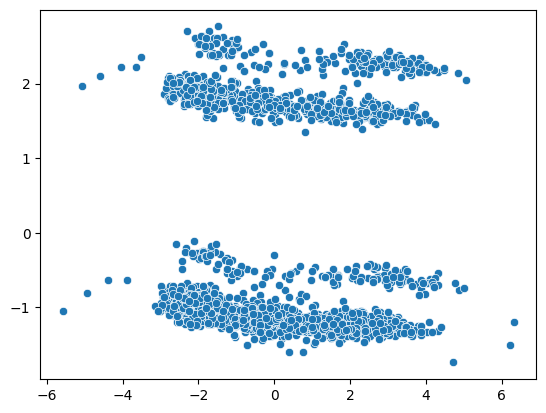

In [72]:
sns.scatterplot(x=X_pca[:,0],y=X_pca[:,1])

In [73]:
pca.explained_variance_ratio_

array([0.25983613, 0.12800844])

It is capturing 25+12=37% variance so majority data is lost

In [74]:
#3D decomposition
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

In [75]:
pca.explained_variance_ratio_

array([0.25983613, 0.12800844, 0.11319971])

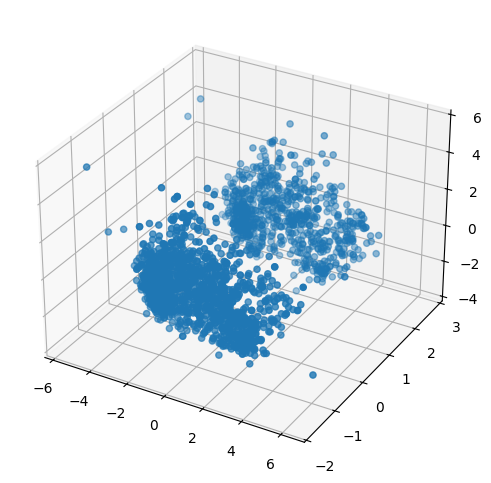

In [76]:
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111,projection='3d')
ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2])

<Axes: >

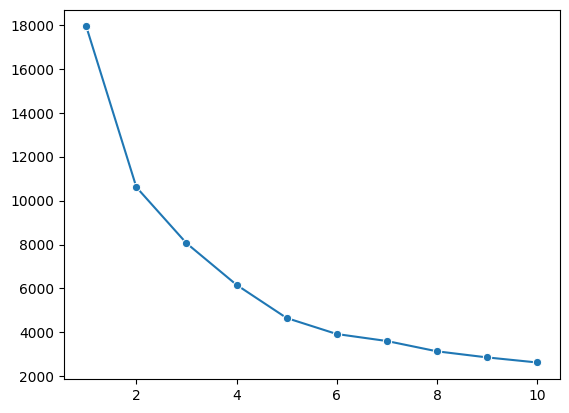

In [77]:
# Identifying k value

wcss = []

for k in range(1,11):
    kmeans = KMeans(n_clusters=k)
    kmeans.fit_predict(X_pca)
    wcss.append(kmeans.inertia_)

sns.lineplot(x=range(1,11),y=wcss,marker='o')

In [78]:
knee = KneeLocator(range(1,11),wcss,curve='convex',direction='decreasing')
knee.knee

np.int64(4)

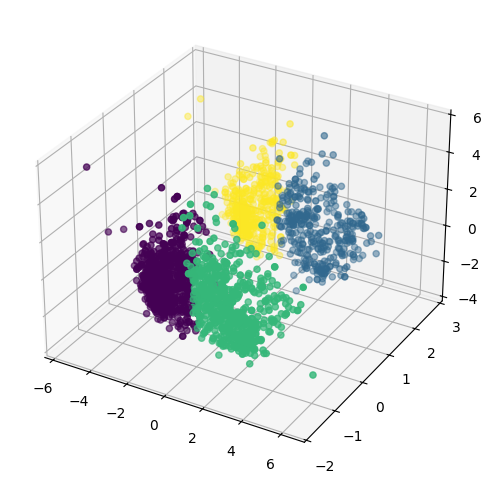

In [79]:
# Applying kmeans clustering
kmeans = KMeans(n_clusters=4,random_state=42)
labels_knn = kmeans.fit_predict(X_pca)

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111,projection='3d')
ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2],c=labels_knn)

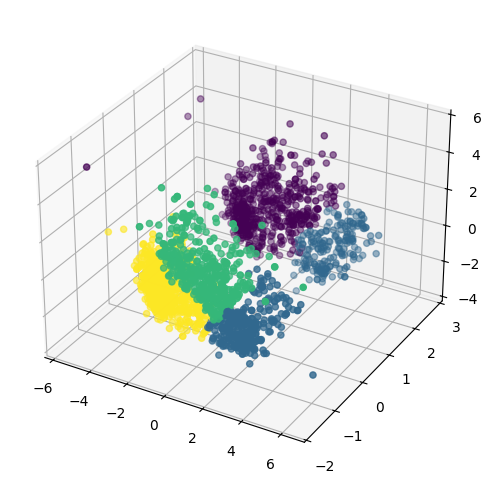

In [80]:
# Applying Agglomerative clustering

agg = AgglomerativeClustering(n_clusters=4)
label = agg.fit_predict(X_pca)

fig = plt.figure(figsize=(8,6))
ax=fig.add_subplot(111,projection='3d')
ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2],c=label)

Kmeans cluster is better than Agglomerative so we will choose Kmeans

In [82]:
df_cleaned['clusters'] = labels_knn

In [83]:
df_cleaned.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Tenure_Days,Total_Spending,Total_Children,Living_With_Alone,Living_With_Partner,clusters
0,1.0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,1
1,1.0,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,3
2,1.0,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,0.0,1.0,2
3,1.0,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,0.0,1.0,0
4,2.0,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0


<Axes: xlabel='clusters', ylabel='count'>

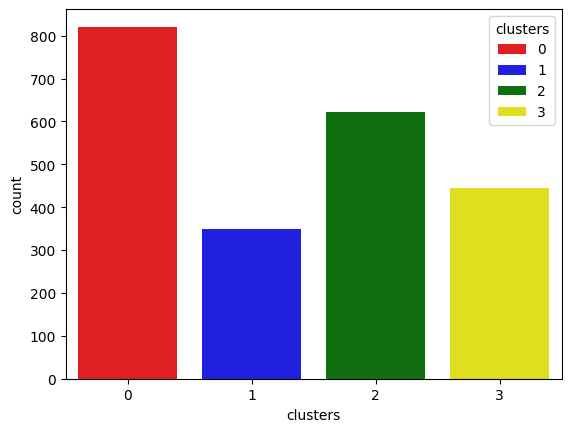

In [86]:
pal = ['red','blue','green','yellow']

sns.countplot(x=df_cleaned['clusters'],palette=pal,hue=df_cleaned['clusters'])

Since Total_Spending and Income had the highest correlation lets analyze the clusters according to total spending and income

<Axes: xlabel='Total_Spending', ylabel='Income'>

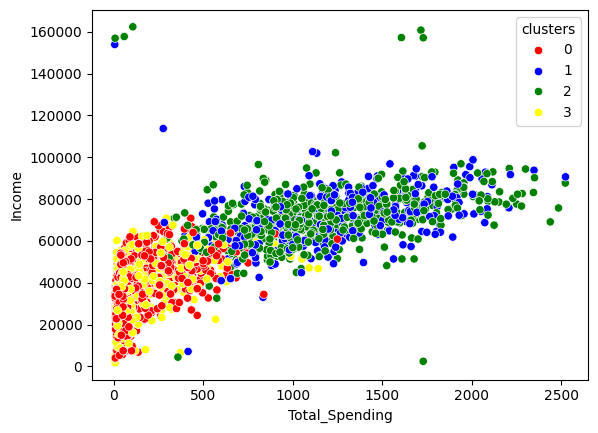

In [87]:
sns.scatterplot(x=df_cleaned['Total_Spending'],y=df_cleaned['Income'],hue=df_cleaned['clusters'],palette=pal)

Red: Low/Moderate Income Low/Moderate Spending
Yellow: Low/Moderate Income Low/Moderate Spending
Green: High Income High Spending
Blue: Moderate/High Income High Spending

In [89]:
cluster_summary = df_cleaned.groupby('clusters').mean()
cluster_summary

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Tenure_Days,Total_Spending,Total_Children,Living_With_Alone,Living_With_Partner
clusters,,,,,,,,,,,,,,,,
0,1.208283,37407.227162,49.269184,2.522533,2.848965,0.773447,3.751523,6.516443,0.009744,0.071864,55.358100,340.125457,164.370280,1.267966,0.0,1.0
1,1.338109,70876.621777,50.515759,1.868195,5.805158,5.051576,8.449857,3.702006,0.005731,0.326648,58.939828,373.532951,1197.873926,0.455587,1.0,0.0
2,1.336554,71007.741546,48.735910,2.156200,5.721417,5.117552,8.526570,3.750403,0.008052,0.159420,59.434783,369.130435,1169.814815,0.582931,0.0,1.0
3,1.229213,37354.973034,48.267416,2.559551,2.746067,0.851685,3.674157,6.566292,0.011236,0.139326,55.622472,342.024719,169.719101,1.267416,1.0,0.0
